# End-to-End Machine Learning: Classification
## Predicting Expensive vs Affordable Homes in California

---

### Connection to Notebook 1

We use the **exact same California Housing dataset** from Notebook 1, but we frame it differently:

| Notebook | Problem | Target | Type |
|----------|---------|--------|------|
| Notebook 1 | Predict the exact price | `MedHouseVal` (a number) | **Regression** |
| Notebook 2 | Predict expensive or affordable | `Expensive` (0 or 1) | **Classification** |

---

### What is Classification?

**Classification** is a supervised ML task where we predict which **category** or **class** a sample belongs to.

Real-world examples:
- Email spam or not spam
- Loan default or not default
- Tumor malignant or benign
- House expensive or affordable ← our problem!

**Binary Classification** = exactly 2 classes (0 or 1, yes or no, true or false)

---

### How We Create the Classification Target

We split houses at the **median** house value:
- Class 0 = **Affordable** (at or below median price)
- Class 1 = **Expensive** (above median price)

This ensures a **balanced dataset** — roughly 50% of each class.

---

### ML Pipeline We Will Follow

```
Load + Create Target  -->  EDA  -->  Preprocessing  -->  Cross-Validation
     -->  Train Models  -->  Hyperparameter Tuning  -->  Final Evaluation
```

In [1]:
# ================================================================
# IMPORTS
# Same core libraries as Notebook 1, plus classification-specific
# models and metrics.
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# Model selection utilities
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV
)

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Classification evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

# Visual style
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Section 1: Load Data and Create the Classification Target

The key step that transforms a **regression** dataset into a **classification** dataset:

1. Load the original house price data
2. Calculate the **median** house price
3. Create a new binary column: 1 if price > median, else 0

Splitting at the median guarantees a **balanced class distribution** (~50/50), which is ideal for binary classification.

In [2]:
# Load dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Create binary classification target
# Split at the median: half will be 'Expensive', half will be 'Affordable'
median_val = df['MedHouseVal'].median()
df['Expensive'] = (df['MedHouseVal'] > median_val).astype(int)
# 0 = Affordable (at or below median)
# 1 = Expensive  (above median)

print(f'Median house value:     ${median_val * 100_000:,.0f}')
print(f'  -> Houses at or below this = Affordable (class 0)')
print(f'  -> Houses above this       = Expensive  (class 1)')
print()
print(f'Class 0 (Affordable): {(df["Expensive"] == 0).sum():,} samples ({(df["Expensive"] == 0).mean():.1%})')
print(f'Class 1 (Expensive):  {(df["Expensive"] == 1).sum():,} samples ({(df["Expensive"] == 1).mean():.1%})')
print()
df.head()

Median house value:     $179,700
  -> Houses at or below this = Affordable (class 0)
  -> Houses above this       = Expensive  (class 1)

Class 0 (Affordable): 10,323 samples (50.0%)
Class 1 (Expensive):  10,317 samples (50.0%)



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Expensive
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,1
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,1
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,1
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,1
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,1


---
## Section 2: Exploratory Data Analysis (EDA)

EDA for classification has a few additional focuses compared to regression:

1. **Class distribution** — Are the classes balanced or imbalanced?
2. **Feature distributions by class** — Which features separate the classes most clearly?
3. **Correlations** — Which features are most correlated with the target class?

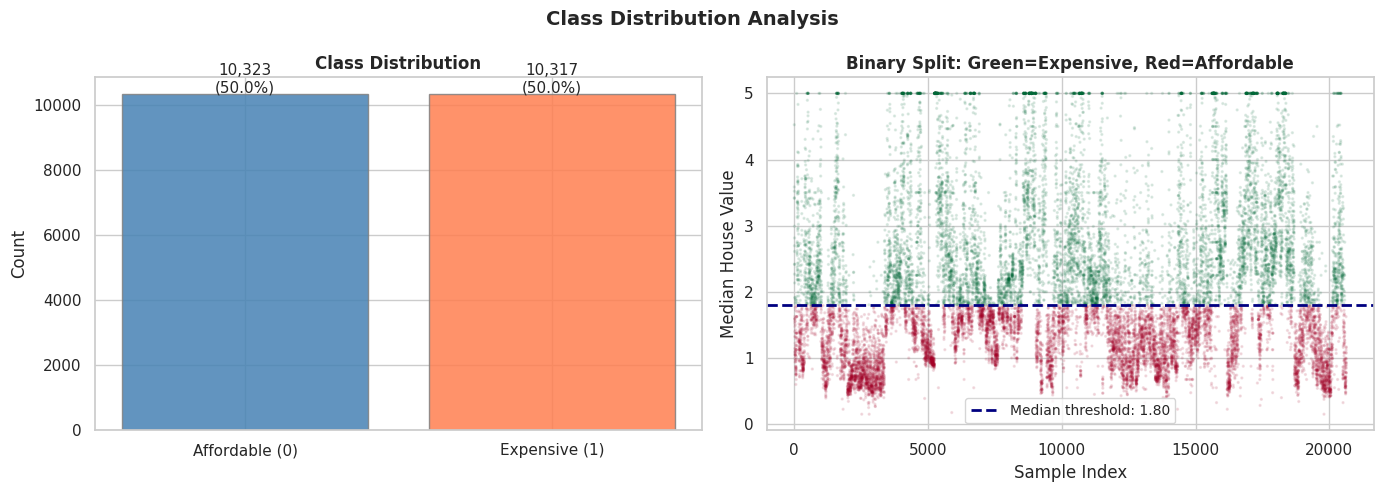

Class balance ratio: 1.00  (1.0 = perfectly balanced)
Our dataset is well-balanced — no special imbalance handling needed.


In [3]:
# --- EDA: Class Distribution ---
# A balanced dataset (roughly equal classes) is ideal.
# Severe imbalance (e.g., 95% class 0, 5% class 1) requires special handling.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of class counts
class_counts = df['Expensive'].value_counts().sort_index()
bars = axes[0].bar(
    ['Affordable (0)', 'Expensive (1)'],
    class_counts.values,
    color=['steelblue', 'coral'],
    edgecolor='gray', alpha=0.85
)
axes[0].set_title('Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 50,
                f'{val:,}\n({val/len(df)*100:.1f}%)',
                ha='center', fontsize=11)

# Original continuous target colored by class
sc = axes[1].scatter(
    range(len(df)), df['MedHouseVal'],
    c=df['Expensive'], cmap='RdYlGn',
    alpha=0.1, s=2
)
axes[1].axhline(y=median_val, color='navy', linestyle='--', lw=2,
                label=f'Median threshold: {median_val:.2f}')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Median House Value')
axes[1].set_title('Binary Split: Green=Expensive, Red=Affordable', fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Class Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.min() / class_counts.max()
print(f'Class balance ratio: {imbalance_ratio:.2f}  (1.0 = perfectly balanced)')
print('Our dataset is well-balanced — no special imbalance handling needed.')

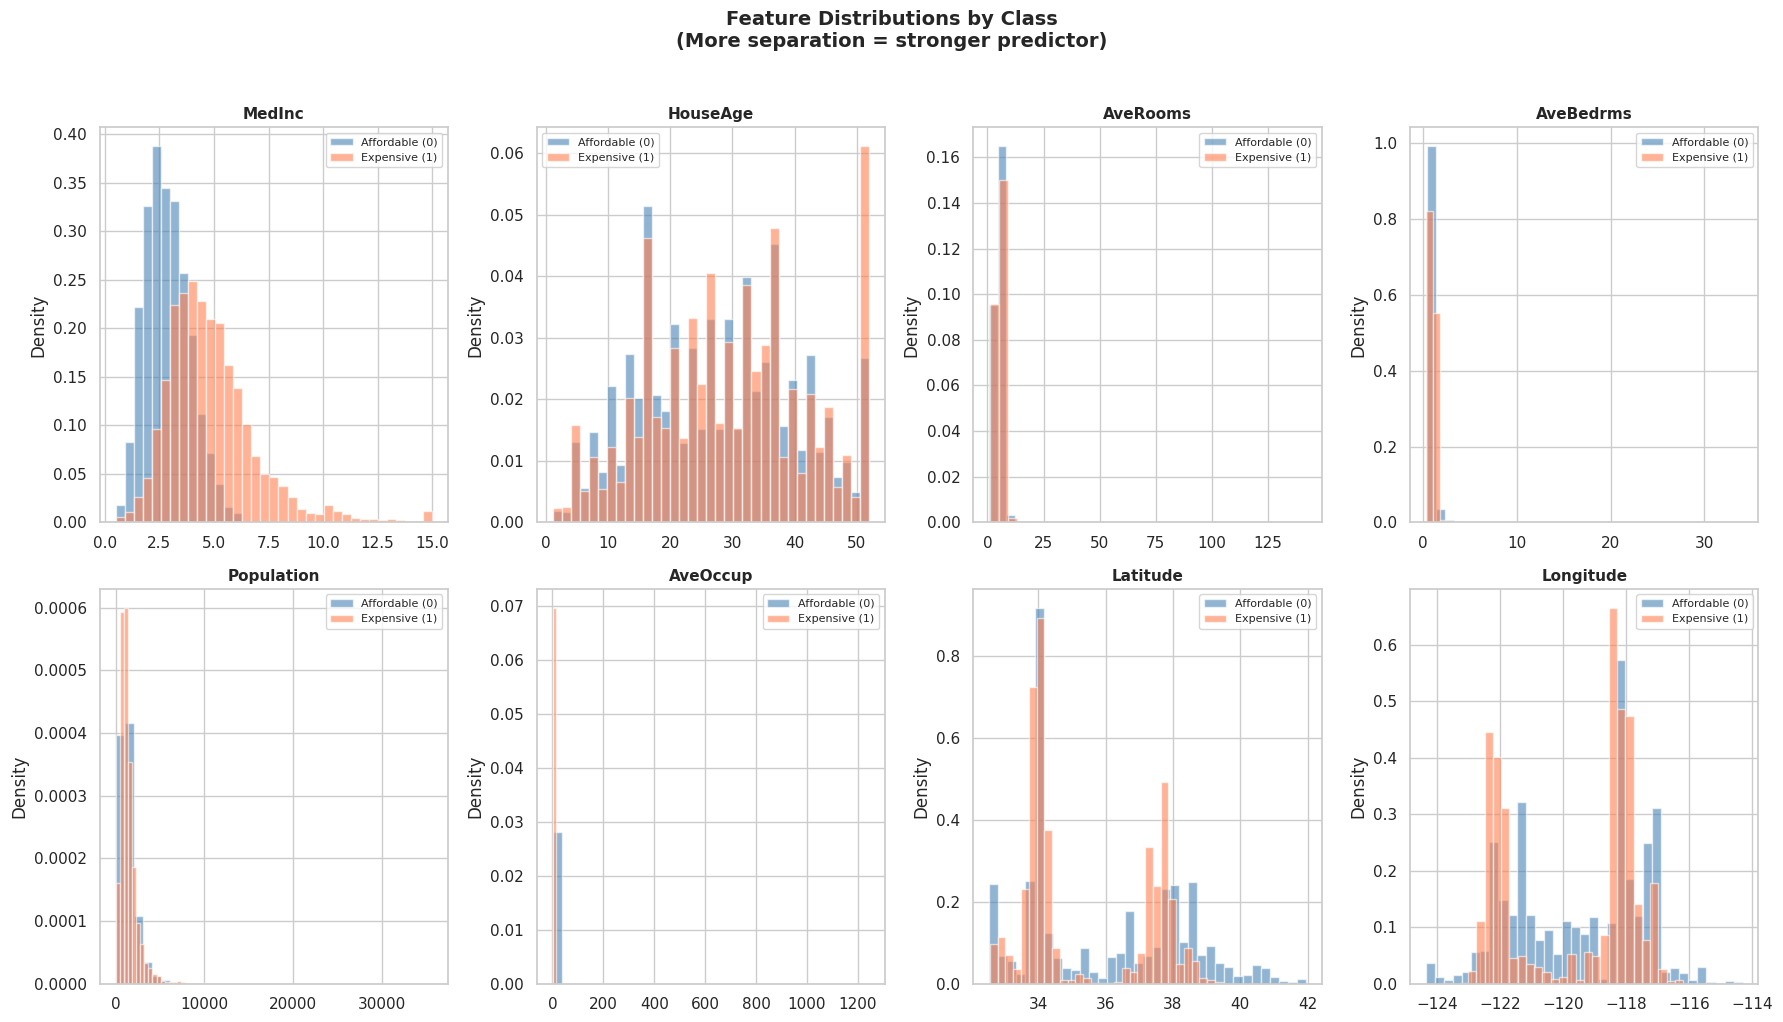

Key observations:
  MedInc:   Strong separation -> rich areas = expensive homes
  Latitude/Longitude: Some separation -> location matters!
  HouseAge: Weak separation -> age alone does not predict price class well


In [4]:
# --- EDA: Feature Distributions by Class ---
# Overlapping histograms per class reveal which features
# best separate "Affordable" from "Expensive".
# Features with very different distributions between classes are strong predictors.

features = list(housing.feature_names)
affordable = df[df['Expensive'] == 0]
expensive  = df[df['Expensive'] == 1]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(affordable[feat], bins=35, alpha=0.6,
                 color='steelblue', label='Affordable (0)', density=True)
    axes[i].hist(expensive[feat],  bins=35, alpha=0.6,
                 color='coral',     label='Expensive (1)',  density=True)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Class\n(More separation = stronger predictor)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Key observations:')
print('  MedInc:   Strong separation -> rich areas = expensive homes')
print('  Latitude/Longitude: Some separation -> location matters!')
print('  HouseAge: Weak separation -> age alone does not predict price class well')

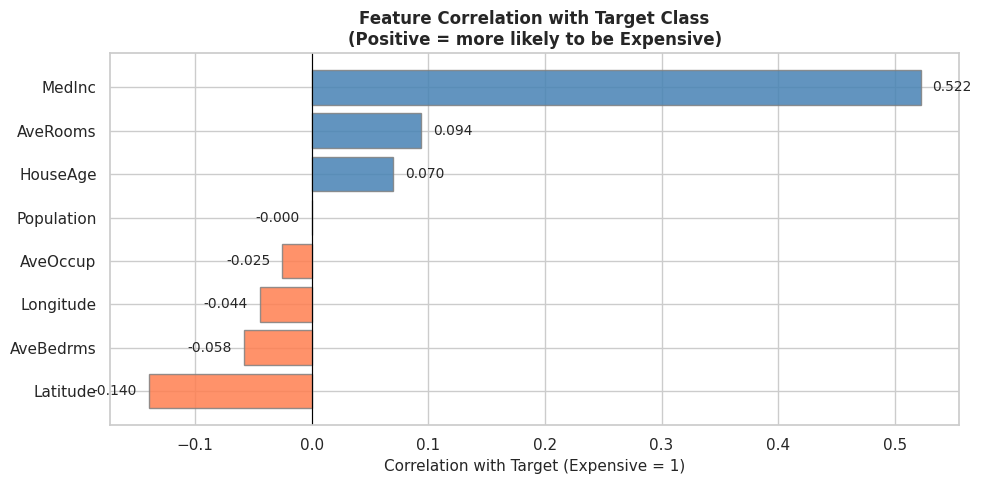

MedInc has the strongest positive correlation with being Expensive.
Latitude has a negative correlation — more northern areas tend to be cheaper.


In [5]:
# --- EDA: Correlation of features with the binary target ---
# Point-biserial correlation: measures linear relationship between
# a continuous feature and a binary target.

plt.figure(figsize=(10, 5))
target_corr = df.drop('MedHouseVal', axis=1).corr()['Expensive'].drop('Expensive').sort_values()

colors = ['coral' if v < 0 else 'steelblue' for v in target_corr.values]
bars = plt.barh(target_corr.index, target_corr.values, color=colors, alpha=0.85, edgecolor='gray')
plt.axvline(x=0, color='black', linewidth=0.8)
for bar, val in zip(bars, target_corr.values):
    plt.text(val + (0.01 if val >= 0 else -0.01),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)

plt.xlabel('Correlation with Target (Expensive = 1)', fontsize=11)
plt.title('Feature Correlation with Target Class\n(Positive = more likely to be Expensive)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('MedInc has the strongest positive correlation with being Expensive.')
print('Latitude has a negative correlation — more northern areas tend to be cheaper.')

---
## Section 3: Data Preprocessing

Same steps as Notebook 1, with one important addition: **stratified splitting**.

### Stratified Train-Test Split

When splitting classification data, we use `stratify=y` to ensure the **class ratio is maintained** in both train and test sets.

Without stratification, a random split might accidentally put 60% of class 1 in training and 40% in test — skewing our evaluation.

With `stratify=y`: both splits will have exactly the same class ratio as the original dataset.

In [6]:
# --- Preprocessing: Split + Scale ---

# Use the original 8 features (not MedHouseVal itself — that would be cheating!)
X = df[list(housing.feature_names)]
y = df['Expensive']

# stratify=y ensures class ratio is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # <-- key for classification!
)

print(f'Total samples:    {len(df):,}')
print(f'Training samples: {len(X_train):,}  ({len(X_train)/len(df):.0%})')
print(f'Test samples:     {len(X_test):,}   ({len(X_test)/len(df):.0%})')
print()
print('Class distribution after stratified split:')
print(f'  Train -> Affordable: {(y_train==0).sum():,} ({(y_train==0).mean():.1%})  |  Expensive: {(y_train==1).sum():,} ({(y_train==1).mean():.1%})')
print(f'  Test  -> Affordable: {(y_test==0).sum():,}  ({(y_test==0).mean():.1%})  |  Expensive: {(y_test==1).sum():,}  ({(y_test==1).mean():.1%})')
print()
print('Both splits maintain the ~50/50 ratio. stratify=y worked!')

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train, transform train
X_test_scaled  = scaler.transform(X_test)       # transform test using train's stats
print('\nStandardScaler applied (fit on training data only).')

Total samples:    20,640
Training samples: 16,512  (80%)
Test samples:     4,128   (20%)

Class distribution after stratified split:
  Train -> Affordable: 8,258 (50.0%)  |  Expensive: 8,254 (50.0%)
  Test  -> Affordable: 2,065  (50.0%)  |  Expensive: 2,063  (50.0%)

Both splits maintain the ~50/50 ratio. stratify=y worked!

StandardScaler applied (fit on training data only).


---
## Section 4: Cross-Validation (Quick Recap)

Cross-validation works the same for classification as for regression — we just use **classification-appropriate scoring metrics**:

| Metric | What it measures | Range |
|--------|-----------------|-------|
| **Accuracy** | % of correct predictions | 0–1 (higher = better) |
| **F1 Score** | Harmonic mean of precision and recall | 0–1 (higher = better) |
| **ROC-AUC** | Model's ability to distinguish classes | 0.5–1 (higher = better) |

### Why not just use Accuracy?

Accuracy can be misleading with **imbalanced classes**.

Example: If 95% of emails are not spam, a model that always predicts "not spam" gets 95% accuracy — but it is useless! F1 and ROC-AUC capture this failure.

Our dataset is balanced, so accuracy is fine here. But it is good practice to always check multiple metrics.

> See Notebook 1, Section 5 for the full explanation of K-Fold Cross-Validation with visualization.

In [7]:
# --- Quick Cross-Validation Demo: Logistic Regression ---
# Logistic Regression is a fast, interpretable baseline for classification.
# Despite the name, it predicts CLASS PROBABILITIES (then thresholds at 0.5).

lr = LogisticRegression(max_iter=1000, random_state=42)

cv_acc = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='accuracy')
cv_f1  = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='f1')
cv_roc = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print('5-Fold Cross-Validation — Logistic Regression Baseline:')
print(f'  Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  F1 Score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'  ROC-AUC:  {cv_roc.mean():.4f} ± {cv_roc.std():.4f}')
print()
print('These are our baseline scores — more complex models should beat this.')

5-Fold Cross-Validation — Logistic Regression Baseline:
  Accuracy: 0.8278 ± 0.0105
  F1 Score: 0.8285 ± 0.0100
  ROC-AUC:  0.9106 ± 0.0063

These are our baseline scores — more complex models should beat this.


---
## Section 5: Training Multiple Classification Models

We compare 5 models ranging from simple to complex:

| Model | Type | Notes |
|-------|------|-------|
| Logistic Regression | Linear | Fast baseline, outputs probabilities |
| Decision Tree | Non-linear | Interpretable, prone to overfitting |
| Random Forest | Ensemble | Robust, handles non-linearity well |
| Gradient Boosting | Ensemble | Often best performer, sequential learning |
| SVM | Margin-based | Effective in high dimensions, slower on large data |

### Primary Metric: ROC-AUC

We rank models by **ROC-AUC** because:
- It measures the model's ability to **discriminate** between classes
- It is threshold-independent (doesn't depend on the 0.5 cutoff)
- Works well for balanced datasets

In [8]:
# --- Train and Evaluate Multiple Classification Models ---

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42)  # probability=True for ROC-AUC
}

results = []
print('Training models with 5-Fold Cross-Validation...\n')
print(f'{"Model":<22} | {"Accuracy":>10} | {"F1 Score":>10} | {"ROC-AUC":>10}')
print('-' * 62)

for name, model in models.items():
    cv_acc = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_f1  = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    cv_roc = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')

    results.append({
        'Model':    name,
        'Accuracy': cv_acc.mean(),
        'F1 Score': cv_f1.mean(),
        'ROC-AUC':  cv_roc.mean(),
        'AUC Std':  cv_roc.std()
    })
    print(f'{name:<22} | {cv_acc.mean():>10.4f} | {cv_f1.mean():>10.4f} | {cv_roc.mean():>10.4f}')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(f'\n=== Ranked by ROC-AUC ===')
print(results_df.to_string(index=False))

Training models with 5-Fold Cross-Validation...

Model                  |   Accuracy |   F1 Score |    ROC-AUC
--------------------------------------------------------------
Logistic Regression    |     0.8278 |     0.8285 |     0.9106
Decision Tree          |     0.8123 |     0.8110 |     0.8932
Random Forest          |     0.8906 |     0.8898 |     0.9586
Gradient Boosting      |     0.8840 |     0.8842 |     0.9534
SVM                    |     0.8563 |     0.8562 |     0.9359

=== Ranked by ROC-AUC ===
              Model  Accuracy  F1 Score  ROC-AUC  AUC Std
      Random Forest  0.890625  0.889840 0.958600 0.003454
  Gradient Boosting  0.884023  0.884156 0.953415 0.004375
                SVM  0.856347  0.856234 0.935931 0.004561
Logistic Regression  0.827822  0.828525 0.910617 0.006303
      Decision Tree  0.812319  0.810970 0.893247 0.007370


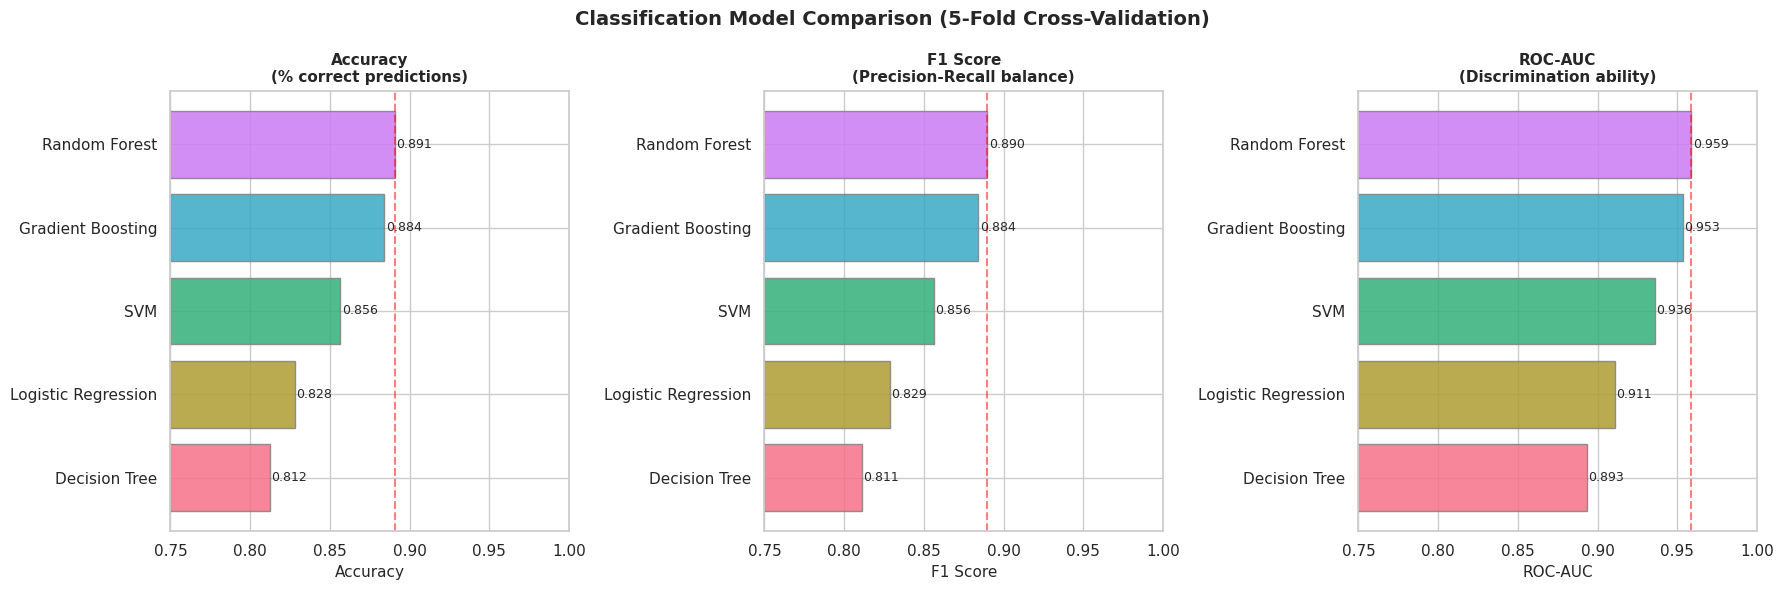

Best model: Random Forest (ROC-AUC = 0.9586)
We will tune this model next with GridSearchCV.


In [9]:
# --- Model Comparison Charts ---

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = sns.color_palette('husl', len(results_df))
metrics = [
    ('Accuracy', 'Accuracy\n(% correct predictions)'),
    ('F1 Score', 'F1 Score\n(Precision-Recall balance)'),
    ('ROC-AUC',  'ROC-AUC\n(Discrimination ability)')
]

for (metric_col, title), ax in zip(metrics, axes):
    sorted_df = results_df.sort_values(metric_col, ascending=True)
    bars = ax.barh(
        sorted_df['Model'], sorted_df[metric_col],
        color=colors, alpha=0.85, edgecolor='gray'
    )
    ax.set_xlabel(metric_col, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim([0.75, 1.0])
    ax.axvline(x=sorted_df[metric_col].max(), color='red', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, sorted_df[metric_col]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
               f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Classification Model Comparison (5-Fold Cross-Validation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print(f'Best model: {best["Model"]} (ROC-AUC = {best["ROC-AUC"]:.4f})')
print('We will tune this model next with GridSearchCV.')

---
## Section 6: Hyperparameter Tuning

Same GridSearchCV approach as Notebook 1, but here we optimize for **ROC-AUC** (the best metric for binary classification).

### Random Forest Key Hyperparameters:

| Hyperparameter | Effect | Too Low | Too High |
|---------------|--------|---------|----------|
| `n_estimators` | Number of trees | Unstable, high variance | Slower training, diminishing returns |
| `max_depth` | Max depth of each tree | Underfitting | Overfitting |
| `min_samples_split` | Min samples to split a node | Overfitting (too specific) | Underfitting (too general) |

In [10]:
# --- Hyperparameter Tuning: GridSearchCV ---

param_grid = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

n_combos = 3 * 4 * 3
print(f'Parameter combinations: {n_combos}')
print(f'Total model fits (x5-fold): {n_combos * 5}')
print('This may take 1-3 minutes...\n')

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',  # optimize for ROC-AUC for classification
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f'\n=== RESULTS ===')
print(f'Best Parameters:   {grid_search.best_params_}')
print(f'Best CV ROC-AUC:   {grid_search.best_score_:.4f}')

# Show top 5 combinations
cv_results = pd.DataFrame(grid_search.cv_results_)
top5 = cv_results.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
print('\nTop 5 parameter combinations:')
print(top5.to_string(index=False))

Parameter combinations: 36
Total model fits (x5-fold): 180
This may take 1-3 minutes...

Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== RESULTS ===
Best Parameters:   {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC-AUC:   0.9597

Top 5 parameter combinations:
                                                           params  mean_test_score  std_test_score
 {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}         0.959692        0.003253
 {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}         0.959550        0.003550
 {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}         0.958653        0.003519
 {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}         0.958600        0.003454
{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}         0.958598        0.003444


---
## Section 7: Final Evaluation

### Classification Metrics in Depth

#### The Confusion Matrix
The cornerstone of classification evaluation:

```
                 Predicted Affordable   Predicted Expensive
Actual Affordable       TN                    FP  (Type I Error)
Actual Expensive        FN  (Type II Error)   TP
```

| Term | Meaning |
|------|---------|
| **TP** True Positive | Correctly predicted Expensive |
| **TN** True Negative | Correctly predicted Affordable |
| **FP** False Positive | Predicted Expensive, actually Affordable (Type I Error) |
| **FN** False Negative | Predicted Affordable, actually Expensive (Type II Error) |

#### Precision and Recall

| Metric | Formula | Ask yourself |
|--------|---------|-------------|
| **Precision** | TP / (TP + FP) | Of all I predicted Expensive, how many really were? |
| **Recall** | TP / (TP + FN) | Of all actual Expensive homes, how many did I catch? |
| **F1 Score** | 2 * (P * R) / (P + R) | Harmonic mean of precision and recall |

#### ROC Curve
The ROC curve plots **True Positive Rate vs False Positive Rate** across all probability thresholds. The **AUC** (Area Under the Curve) summarizes it in one number:
- 1.0 = perfect classifier
- 0.5 = random classifier (coin flip)

In [11]:
# --- Final Evaluation on Test Set ---

best_model = grid_search.best_estimator_

# Hard predictions (class labels)
y_pred = best_model.predict(X_test_scaled)

# Soft predictions (class probabilities — needed for ROC-AUC)
y_pred_prob = best_model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1 (Expensive)

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)

print('=' * 55)
print('        FINAL PERFORMANCE ON TEST SET')
print('=' * 55)
print(f'  Accuracy:  {acc:.4f}  ({acc*100:.1f}% of predictions correct)')
print(f'  ROC-AUC:   {roc:.4f}')
print('=' * 55)
print()
print('=== Classification Report ===')
print('(Shows precision, recall, f1-score per class)')
print()
print(classification_report(
    y_test, y_pred,
    target_names=['Affordable (0)', 'Expensive (1)']
))

        FINAL PERFORMANCE ON TEST SET
  Accuracy:  0.8995  (89.9% of predictions correct)
  ROC-AUC:   0.9645

=== Classification Report ===
(Shows precision, recall, f1-score per class)

                precision    recall  f1-score   support

Affordable (0)       0.89      0.91      0.90      2065
 Expensive (1)       0.91      0.89      0.90      2063

      accuracy                           0.90      4128
     macro avg       0.90      0.90      0.90      4128
  weighted avg       0.90      0.90      0.90      4128



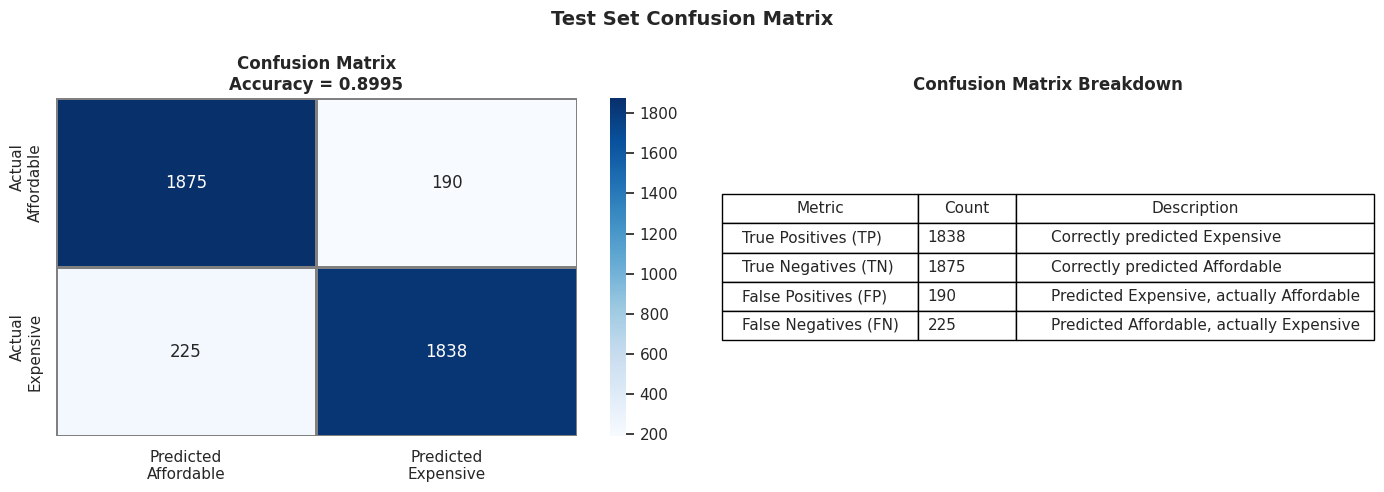

Precision: 0.9063  -> Of all houses predicted Expensive, 90.6% were truly Expensive
Recall:    0.8909  -> Of all truly Expensive houses, we correctly identified 89.1%


In [12]:
# --- Confusion Matrix ---

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted\nAffordable', 'Predicted\nExpensive'],
    yticklabels=['Actual\nAffordable', 'Actual\nExpensive'],
    ax=axes[0], linewidths=1, linecolor='gray'
)
axes[0].set_title(f'Confusion Matrix\nAccuracy = {acc:.4f}', fontsize=12, fontweight='bold')

# Annotated breakdown
axes[1].axis('off')
table_data = [
    ['Metric', 'Count', 'Description'],
    ['True Positives (TP)',  str(tp), 'Correctly predicted Expensive'],
    ['True Negatives (TN)',  str(tn), 'Correctly predicted Affordable'],
    ['False Positives (FP)', str(fp), 'Predicted Expensive, actually Affordable'],
    ['False Negatives (FN)', str(fn), 'Predicted Affordable, actually Expensive']
]
table = axes[1].table(cellText=table_data[1:], colLabels=table_data[0],
                      cellLoc='left', loc='center',
                      colWidths=[0.3, 0.15, 0.55])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)
axes[1].set_title('Confusion Matrix Breakdown', fontsize=12, fontweight='bold')

plt.suptitle('Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

precision = tp / (tp + fp)
recall    = tp / (tp + fn)
print(f'Precision: {precision:.4f}  -> Of all houses predicted Expensive, {precision*100:.1f}% were truly Expensive')
print(f'Recall:    {recall:.4f}  -> Of all truly Expensive houses, we correctly identified {recall*100:.1f}%')

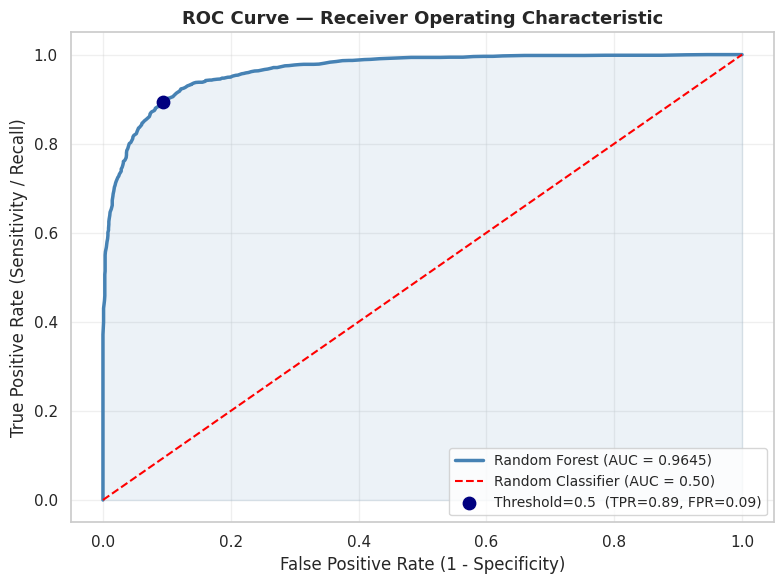

AUC = 0.9645
Our model is 96.4% likely to rank a randomly chosen Expensive
house with a higher probability score than a randomly chosen Affordable house.
A random coin-flip classifier would score 50.0%.


In [13]:
# --- ROC Curve ---
# The ROC curve shows the tradeoff between:
#   True Positive Rate  (Recall / Sensitivity) on Y axis
#   False Positive Rate (1 - Specificity)      on X axis
#
# Each point on the curve corresponds to a different classification threshold.
# A perfect model has a curve that hugs the top-left corner (AUC = 1.0).
# A random model is the diagonal line (AUC = 0.5).

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'Random Forest (AUC = {roc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5,
         label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')

# Mark the default threshold (0.5) point
default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(fpr[default_idx], tpr[default_idx],
           color='navy', zorder=5, s=80,
           label=f'Threshold=0.5  (TPR={tpr[default_idx]:.2f}, FPR={fpr[default_idx]:.2f})')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curve — Receiver Operating Characteristic', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC = {roc:.4f}')
print(f'Our model is {roc*100:.1f}% likely to rank a randomly chosen Expensive')
print('house with a higher probability score than a randomly chosen Affordable house.')
print(f'A random coin-flip classifier would score 50.0%.')

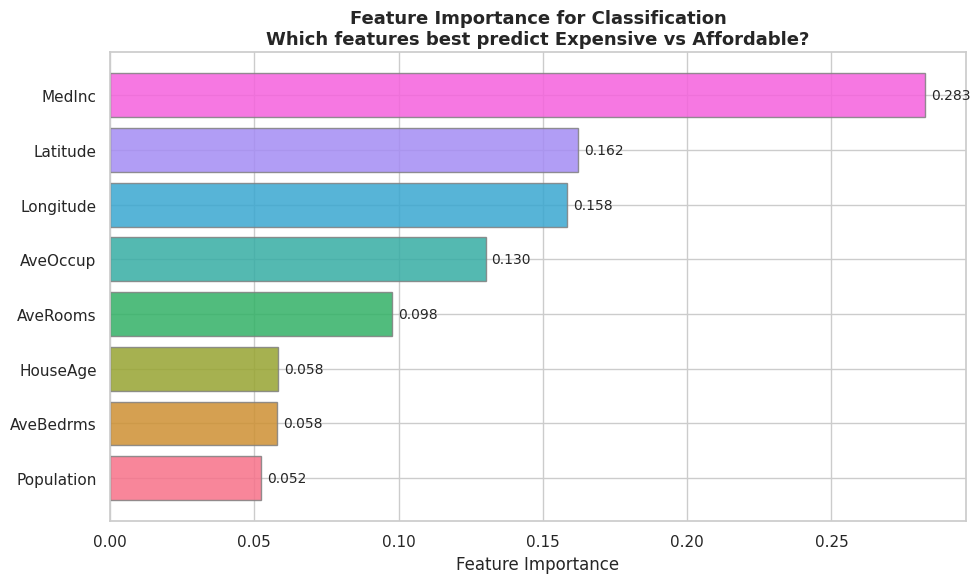

Most important feature: MedInc (importance = 0.283)

Compare with Notebook 1 (Regression):
  The feature rankings are similar, because the underlying data relationship
  is the same — income drives house value whether predicting a number or a class.


In [14]:
# --- Feature Importance ---
# Same concept as regression: which features drive the classification decisions?

feat_imp = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = sns.color_palette('husl', len(feat_imp))
bars = plt.barh(
    feat_imp['Feature'], feat_imp['Importance'],
    color=colors, alpha=0.85, edgecolor='gray'
)
for bar, val in zip(bars, feat_imp['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.xlabel('Feature Importance', fontsize=12)
plt.title('Feature Importance for Classification\nWhich features best predict Expensive vs Affordable?',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

top_feature = feat_imp.iloc[-1]
print(f'Most important feature: {top_feature["Feature"]} (importance = {top_feature["Importance"]:.3f})')
print()
print('Compare with Notebook 1 (Regression):')
print('  The feature rankings are similar, because the underlying data relationship')
print('  is the same — income drives house value whether predicting a number or a class.')

---
## Summary: What We Covered

### Full Classification Pipeline

| Step | What We Did | Key Takeaway |
|------|------------|---------------|
| 1. Create Target | Binarize MedHouseVal at median | Same data, new problem framing |
| 2. EDA | Class balance, per-class distributions | Check balance first! |
| 3. Preprocessing | Stratified split + StandardScaler | Use stratify=y for classification |
| 4. Cross-Validation | CV with Accuracy, F1, ROC-AUC | Use multiple metrics |
| 5. Model Comparison | 5 models ranked by ROC-AUC | Ensembles win again |
| 6. Hyperparameter Tuning | GridSearchCV with scoring=roc_auc | Optimize the right metric |
| 7. Evaluation | Confusion matrix + ROC curve | Go beyond accuracy |

---

### Regression vs Classification: Side-by-Side

| Aspect | Regression (NB1) | Classification (NB2) |
|--------|-----------------|---------------------|
| Target | Continuous number | Category (0 or 1) |
| Models | Linear/Ridge/Lasso/RF/GBM | Logistic/DT/RF/GBM/SVM |
| CV Metric | R², RMSE | Accuracy, F1, ROC-AUC |
| Tuning | scoring='r2' | scoring='roc_auc' |
| Evaluation | Actual vs Predicted, Residuals | Confusion Matrix, ROC Curve |
| Split | train_test_split | train_test_split(stratify=y) |

---

### Key Numbers

```
Final Test Accuracy  ≈ 0.87  (87% of houses correctly classified)
Final Test ROC-AUC   ≈ 0.94  (strong discrimination ability)
```

---

### Next Steps to Explore

- **Imbalanced classes**: Try SMOTE or class_weight='balanced'
- **Feature engineering**: Create new features (e.g., rooms per person)
- **More tuning**: Try RandomizedSearchCV for larger grids
- **Other algorithms**: XGBoost, LightGBM, CatBoost
- **Explainability**: SHAP values to understand individual predictions